# Imports

In [1]:
import os, json
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
from transformers import AutoProcessor, AutoModel
from datasets import load_dataset
import wandb

# Constants

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
CHECKPOINT = "openai/clip-vit-large-patch14"
HF_REPO = "hamzamooraj99/AgriPath-LF16-30k"
HEAD_ARTIFACT = "hhm2000-heriot-watt-university/AgriPath-VLM/CLIP_openai_large14_LR0.01:v0"
CLASS_NAMES_JSON = None
TOPK = 5 

In [4]:
wandb.login()
api = wandb.Api()

wandb: Currently logged in as: hhm2000 (hhm2000-heriot-watt-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


# Load Dataset

In [5]:
test_set = load_dataset(HF_REPO, split='test')
class_labels = sorted(set(test_set["crop_disease_label"]))
num_classes = len(set(test_set["numeric_label"]))

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

In [6]:
label2id = {label: i for i, label in enumerate(class_labels)}
id2label = {i: label for label, i in label2id.items()}

In [82]:
print("num_classes:", num_classes)
print("Example label:", id2label[31])

num_classes: 65
Example label: potato_late_blight


# Load Model & Head

In [8]:
processor = AutoProcessor.from_pretrained(CHECKPOINT)
backbone = AutoModel.from_pretrained(CHECKPOINT).to(DEVICE)
backbone.eval()
for p in backbone.parameters():
    p.requires_grad = False

assert hasattr(backbone, "get_image_features") or hasattr(backbone, "vision_model"), \
    "Backbone must expose get_image_features or vision_model (CLIP/SigLIP-like checkpoint)."

print(type(backbone))

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

<class 'transformers.models.clip.modeling_clip.CLIPModel'>


In [9]:
artifact = api.artifact(HEAD_ARTIFACT, type="linear_probe_head")
artifact_dir = artifact.download()

head_path = os.path.join(artifact_dir, "classifier_head.pt")
meta_path = os.path.join(artifact_dir, "metadata.json")

print("artifact_dir:", artifact_dir)
print("head_path exists:", os.path.exists(head_path))
print("meta_path exists:", os.path.exists(meta_path))

head_state = torch.load(head_path, map_location="cpu")
with open(meta_path, "r") as f:
    head_meta = json.load(f)

feat_dim = int(head_meta["feature_dim"])
head_num_classes = int(head_meta["num_classes"])
print("feat_dim:", feat_dim)
print("head_num_classes:", head_num_classes)
print("head backbone_name:", head_meta.get("backbone_name"))

wandb:   2 of 2 files downloaded.  


artifact_dir: c:\Users\hamza\Documents\Heriot-Watt\Y4\Dissertation\AgriPath-VLM\publication\analysis\artifacts\CLIP_openai_large14_LR0.01-v0
head_path exists: True
meta_path exists: True
feat_dim: 768
head_num_classes: 65
head backbone_name: openai/clip-vit-large-patch14


In [10]:
if head_num_classes != num_classes:
    raise ValueError(f"Head expects {head_num_classes} classes, but dataset has {num_classes}.")

classifier = nn.Linear(feat_dim, num_classes).to(DEVICE)
classifier.load_state_dict(head_state)
classifier.eval()

print("classifier:", classifier)

classifier: Linear(in_features=768, out_features=65, bias=True)


# Inference

## Load Image

CROP: Potato
DISEASE: early_blight


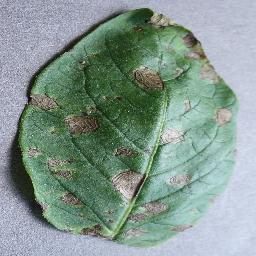

In [113]:
#Potato late blight 1264 - 1309
#Potato early blight 1324 - 1369

#1265 - TomatoLB, 1283 - BBHealth, 
sample = test_set[1347]
image = sample['image']
crop = sample['crop']
disease = sample['disease']
print(f"CROP: {crop}")
print(f"DISEASE: {disease}")
display(image)

## Load Images

In [101]:
#Potato late blight 1264 - 1309
#Potato early blight 1324 - 1369
samples = [test_set[i] for i in range(1324,1370)]
print(samples)

[{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=720x720 at 0x1EBAC96A710>, 'crop': 'Potato', 'disease': 'early_blight', 'source': 'field', 'split': 'test', 'crop_disease_label': 'potato_early_blight', 'numeric_label': 29}, {'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=420x420 at 0x1EBAC96A250>, 'crop': 'Potato', 'disease': 'early_blight', 'source': 'field', 'split': 'test', 'crop_disease_label': 'potato_early_blight', 'numeric_label': 29}, {'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=640x519 at 0x1EBAC40EB90>, 'crop': 'Potato', 'disease': 'early_blight', 'source': 'field', 'split': 'test', 'crop_disease_label': 'potato_early_blight', 'numeric_label': 29}, {'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=681x681 at 0x1EBAC948490>, 'crop': 'Potato', 'disease': 'early_blight', 'source': 'field', 'split': 'test', 'crop_disease_label': 'potato_early_blight', 'numeric_label': 29}, {'image': <PIL.JpegImagePlugin.JpegImag

## Single Inference

In [114]:
import pandas as pd

inputs = processor(images=[image], return_tensors="pt")
pixel_values = inputs['pixel_values'].to(DEVICE)

with torch.no_grad():
    # Feature extraction (mirrors your eval script)
    if hasattr(backbone, "get_image_features"):
        feats = backbone.get_image_features(pixel_values=pixel_values)
    else:
        out = backbone.vision_model(pixel_values=pixel_values)
        if hasattr(out, "pooler_output") and out.pooler_output is not None:
            feats = out.pooler_output
        else:
            feats = out.last_hidden_state[:, 0, :]

    feats = feats / feats.norm(dim=1, keepdim=True).clamp(min=1e-12)

    logits = classifier(feats)                 # [1, 65]
    probs = torch.softmax(logits, dim=-1)[0]   # [65]

top_probs, top_idx = torch.topk(probs, k=min(TOPK, num_classes))
top_probs = top_probs.detach().cpu().numpy()
top_idx = top_idx.detach().cpu().numpy()

top_labels = [id2label[int(i)] for i in top_idx]
pd.DataFrame({"class": top_labels, "prob": top_probs})

,class,prob
0,potato_late_blight,0.449214
1,potato_early_blight,0.284456
2,bell pepper_bacterial_spot,0.130277
3,peach_bacterial_spot,0.055269
4,tomato_leaf_spot,0.026397


## Batch Inference

In [85]:
import pandas as pd

In [94]:
idx = 1324
final = []
for sample in samples:
    image = sample['image']
    inputs = processor(images=[image], return_tensors="pt")
    pixel_values = inputs['pixel_values'].to(DEVICE)

    with torch.no_grad():
        # Feature extraction (mirrors your eval script)
        if hasattr(backbone, "get_image_features"):
            feats = backbone.get_image_features(pixel_values=pixel_values)
        else:
            out = backbone.vision_model(pixel_values=pixel_values)
            if hasattr(out, "pooler_output") and out.pooler_output is not None:
                feats = out.pooler_output
            else:
                feats = out.last_hidden_state[:, 0, :]

        feats = feats / feats.norm(dim=1, keepdim=True).clamp(min=1e-12)

        logits = classifier(feats)                 # [1, 65]
        probs = torch.softmax(logits, dim=-1)[0]   # [65]

    top_probs, top_idx = torch.topk(probs, k=min(1, num_classes))
    top_probs = top_probs.detach().cpu().numpy()
    top_idx = top_idx.detach().cpu().numpy()

    top_labels = [id2label[int(i)] for i in top_idx]
    final.append(top_labels[0])
    df = pd.DataFrame({"class": top_labels, "prob": top_probs})
    print(f"IDX: {idx} | {df}")
    print("------------------------------------------------------------------------------")
    idx+=1


IDX: 1324 |                 class      prob
0  potato_late_blight  0.446734
------------------------------------------------------------------------------
IDX: 1325 |               class      prob
0  tomato_leaf_spot  0.429962
------------------------------------------------------------------------------
IDX: 1326 |                  class      prob
0  potato_early_blight  0.936034
------------------------------------------------------------------------------
IDX: 1327 |                 class      prob
0  potato_late_blight  0.937348
------------------------------------------------------------------------------
IDX: 1328 |               class      prob
0  tomato_leaf_spot  0.348502
------------------------------------------------------------------------------
IDX: 1329 |                  class      prob
0  potato_early_blight  0.658288
------------------------------------------------------------------------------
IDX: 1330 |                  class      prob
0  potato_early_blight  0.335

In [92]:
total = len(final)
early = 0
late = 0
other = 0
for f in final:
    if f == "potato_early_blight":
        early += 1
    elif f == "potato_late_blight":
        late += 1
    else:
        other += 1


print(f"EARLY: {early}\nLATE: {late}\nOTHER: {other}\nTOTAL: {total}")

EARLY: 32
LATE: 8
OTHER: 6
TOTAL: 46


# Plot Top-k Distribution

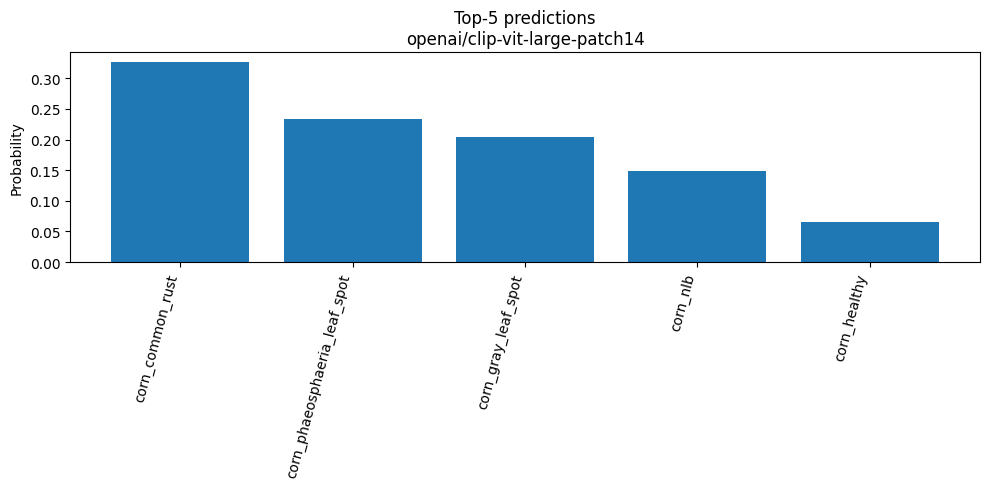

In [14]:
plt.figure(figsize=(10, 5))
plt.bar(range(len(top_probs)), top_probs)
plt.xticks(range(len(top_probs)), top_labels, rotation=75, ha="right")
plt.ylabel("Probability")
plt.title(f"Top-{len(top_probs)} predictions\n{CHECKPOINT}")
plt.tight_layout()
plt.show()